## Processador de Entrada (Fuzzificação)

In [1]:
# Bibliotecas
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

from skfuzzy import control as ctrl

### Antecedente

In [ ]:
# Variáveis fuzzy
# Antecedentes (inputs)
AoL = ctrl.Antecedent(np.arange(0, 70, 0.001), 'AoL') # cm²
EgL = ctrl.Antecedent(np.arange(0, 5, 0.001), 'EgL') # mm

In [ ]:
# Funções de pertinência dos antecedentes Trapezoidal
# Aqui precisa do especialista para definir os valores de cada função de pertinência
""" Só um teste """
AoL['Pequeno'] = fuzz.trapmf(AoL.universe, [0,0,10,20])
AoL['Médio'] = fuzz.trapmf(AoL.universe, [10,20,40,50])
AoL['Grande'] = fuzz.trapmf(AoL.universe, [40,50,70,70])

EgL['Pequeno'] = fuzz.trapmf(EgL.universe, [0,0,1,2])
EgL['Médio'] = fuzz.trapmf(EgL.universe, [1,2,3,4])
EgL['Grande'] = fuzz.trapmf(EgL.universe, [3,4,5,5])

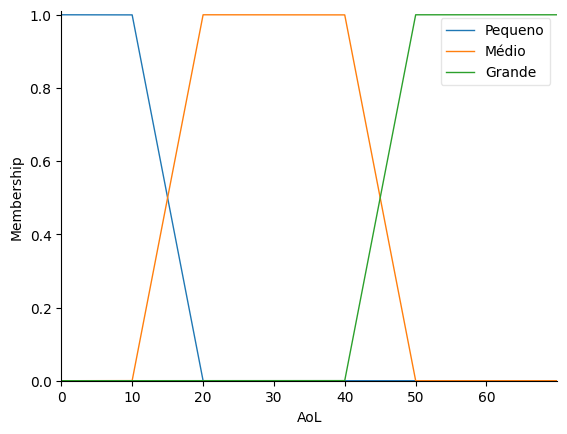

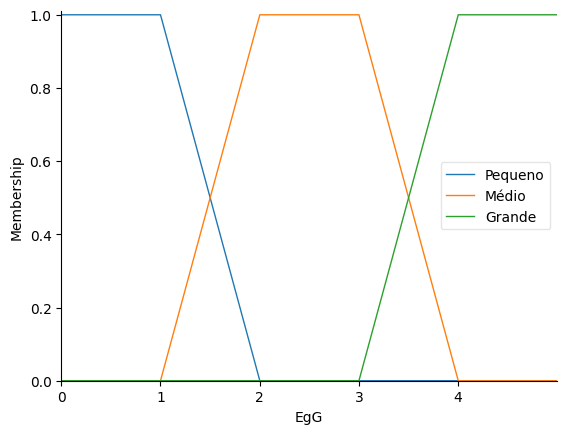

In [ ]:
# Plot do gráfico dos antecedentes
AoL.view()
EgL.view()
plt.show()

### Consequente

In [ ]:
# Consequente (output) "qualidade do fenótipo do boi" 
# Perguntar para a Amanda.
qualidade = ctrl.Consequent(np.arange(0, 1, 0.001), 'qualidade do fenótipo do boi')

qualidade['Ruim'] = fuzz.trapmf(qualidade.universe, [0,0,0.2,0.4])
qualidade['Regular'] = fuzz.trapmf(qualidade.universe, [0.2,0.4,0.6,0.8])
qualidade['Boa'] = fuzz.trapmf(qualidade.universe, [0.6,0.8,1,1])

/home/victors/Documents/Codigos_Mestrado/.venv/lib/python3.11/site-packages/skfuzzy/control/fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


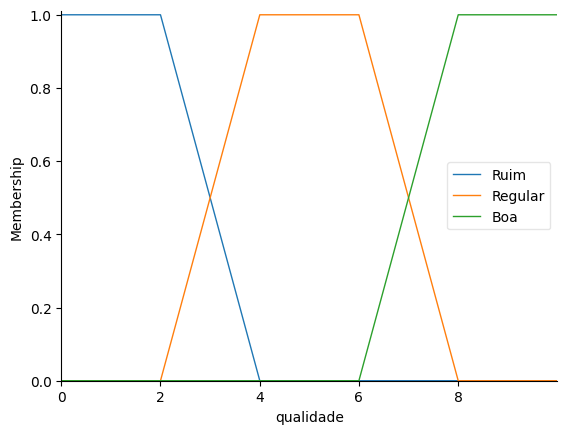

In [17]:
qualidade.view()
plt.show()

## Base de Regras

In [ ]:
# Regras de inferência fuzzy
# Precisa do especialista para definir as regras de inferência fuzzy
rule1 = ctrl.Rule(AoL['Pequeno'] & EgL['Pequeno'], qualidade['Ruim'])
rule2 = ctrl.Rule(AoL['Pequeno'] & EgL['Médio'], qualidade['Ruim'])
rule3 = ctrl.Rule(AoL['Pequeno'] & EgL['Grande'], qualidade['Regular'])
rule4 = ctrl.Rule(AoL['Médio'] & EgL['Pequeno'], qualidade['Ruim'])
rule5 = ctrl.Rule(AoL['Médio'] & EgL['Médio'], qualidade['Regular'])
rule6 = ctrl.Rule(AoL['Médio'] & EgL['Grande'], qualidade['Boa'])
rule7 = ctrl.Rule(AoL['Grande'] & EgL['Pequeno'], qualidade['Regular'])
rule8 = ctrl.Rule(AoL['Grande'] & EgL['Médio'], qualidade['Boa'])
rule9 = ctrl.Rule(AoL['Grande'] & EgL['Grande'], qualidade['Boa'])

## Máquina de inferência Fuzzy e Defuzzificação

In [ ]:
# O métido utilizado para a Inferência é o método de Mamdani
sistema = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9])
# O método utilizado para a defuzzificação é o método do Centro de Gravidade (Centroid)
# G(C) = (\sum^n_{i=0}z_i * C(z_i)) / (\sum^n_{i=0}C(z_i))
simulacao = ctrl.ControlSystemSimulation(sistema)

### Testando o SBRF

6.243943703604922


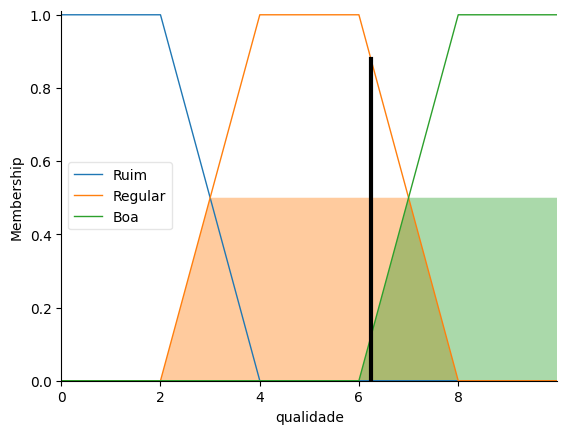

In [ ]:
simulacao.input['AoL'] = 45
simulacao.input['EgL'] = 2
simulacao.compute()
print(simulacao.output['qualidade do fenótipo do boi'])
qualidade.view(simulacao)
plt.show()